<a href="https://colab.research.google.com/github/SAYAMOHAN/PhishGuardXAI/blob/main/notebooks/Preprocessed_phishing_site_urls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import neccessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
df = pd.read_csv("/content/phishing_site_urls.csv")
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


Dimensions of the dataset

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (60065, 2)


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60065 entries, 0 to 60064
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URL     60065 non-null  object
 1   Label   60064 non-null  object
dtypes: object(2)
memory usage: 938.6+ KB


Column names

In [ ]:
print(df.columns)

Index(['URL', 'Label'], dtype='object')


Check for missing values

In [ ]:
df.isnull().sum()

,0
URL,0
Label,1


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
URL,0
Label,0


Check for duplicate rows

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


Remove duplicate rows

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.shape)

(60062, 2)


Check class distribution

In [ ]:
df["Label"].value_counts()

,count
Label,
bad,47902
good,12160


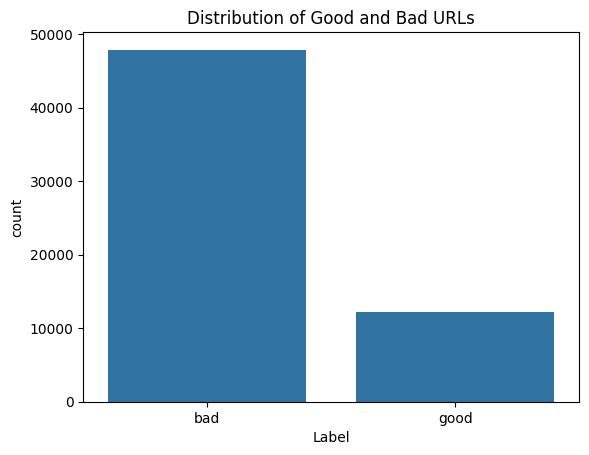

In [ ]:
sns.countplot(x="Label", data=df)
plt.title("Distribution of Good and Bad URLs")
plt.show()

Label Encoding

In [ ]:
df["Label"] = df["Label"].map({
    "good": 0,
    "bad": 1
})

In [ ]:
df["Label"].value_counts()

,count
Label,
1,47902
0,12160


In [ ]:
df = df.dropna(subset=['Label'])
df["Label"] = df["Label"].astype(int)

In [ ]:
df["Label"].value_counts()

,count
Label,
1,47902
0,12160


URL Feature Extraction

In [ ]:
df["URL_Length"] = df["URL"].apply(len)
df["No_of_Dots"] = df["URL"].str.count(r"\.")
df["No_of_Hyphens"] = df["URL"].str.count("-")
df["No_of_Digits"] = df["URL"].str.count(r"\d")
df["Has_HTTPS"] = df["URL"].str.contains("https").astype(int)

In [ ]:
df.head()

,URL,Label,URL_Length,No_of_Dots,No_of_Hyphens,No_of_Digits,Has_HTTPS
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1,225,6,4,58,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,1,81,5,2,1,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1,177,7,1,47,0
3,mail.printakid.com/www.online.americanexpress....,1,60,6,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,1,116,1,1,21,0


In [ ]:
# Count special characters
df["No_of_Slashes"] = df["URL"].str.count("/")
df["No_of_Underscores"] = df["URL"].str.count("_")
df["No_of_QuestionMarks"] = df["URL"].str.count(r"\?")
df["No_of_EqualSigns"] = df["URL"].str.count("=")
df["No_of_At"] = df["URL"].str.count("@")

# Check if URL contains an IP address
import re

def has_ip(url):
    pattern = r'(\d{1,3}\.){3}\d{1,3}'
    return 1 if re.search(pattern, url) else 0

df["Has_IP"] = df["URL"].apply(has_ip)

In [ ]:
df.head()

,URL,Label,URL_Length,No_of_Dots,No_of_Hyphens,No_of_Digits,Has_HTTPS,No_of_Slashes,No_of_Underscores,No_of_QuestionMarks,No_of_EqualSigns,No_of_At,Has_IP
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1,225,6,4,58,0,10,4,1,4,0,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,1,81,5,2,1,0,4,1,0,2,0,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1,177,7,1,47,0,11,0,0,0,0,0
3,mail.printakid.com/www.online.americanexpress....,1,60,6,0,0,0,2,0,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,1,116,1,1,21,0,10,0,1,0,0,0


Train the Initial LightGBM Model

In [ ]:
!pip install lightgbm

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

Selecct the features

In [ ]:
features = [
    "URL_Length",
    "No_of_Dots",
    "No_of_Hyphens",
    "No_of_Digits",
    "Has_HTTPS",
    "No_of_Slashes",
    "No_of_Underscores",
    "No_of_QuestionMarks",
    "No_of_EqualSigns",
    "No_of_At",
    "Has_IP"
]

X = df[features]
y = df["Label"]

Split the dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train LightGBM

In [ ]:
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 38346, number of negative: 9703
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 48049, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798060 -> initscore=1.374215
[LightGBM] [Info] Start training from score 1.374215


LGBMClassifier(random_state=42)

Evaluate LightGBM Model

In [ ]:
y_pred = model.predict(X_test)

#accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8559061017231333
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.57      0.62      2457
           1       0.89      0.93      0.91      9556

    accuracy                           0.86     12013
   macro avg       0.78      0.75      0.77     12013
weighted avg       0.85      0.86      0.85     12013



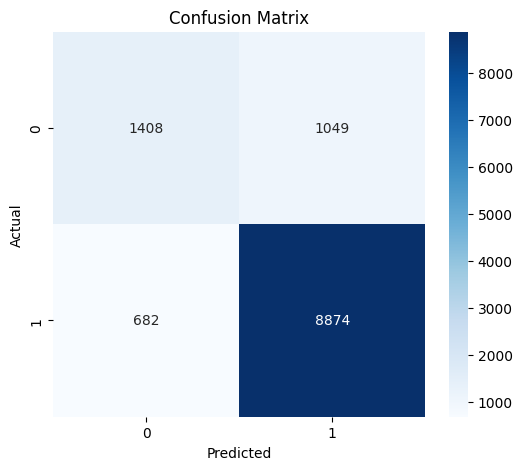

In [ ]:
#confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import importlib # Import importlib

# Reload matplotlib.pyplot to ensure plt.xlabel is reset
importlib.reload(plt)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

DATASET VERIFICATION AND LightGBM IMPROVEMENT

In [ ]:
# Dataset Verification

print("Dataset shape:", df.shape)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nLabel distribution:")
print(df["Label"].value_counts())

print("\nLabel distribution (%):")
print(df["Label"].value_counts(normalize=True) * 100)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (60062, 13)

Number of rows: 60062
Number of columns: 13

Label distribution:
Label
1    47902
0    12160
Name: count, dtype: int64

Label distribution (%):
Label
1    79.754254
0    20.245746
Name: proportion, dtype: float64

Duplicate rows: 0

Missing values:
URL                    0
Label                  0
URL_Length             0
No_of_Dots             0
No_of_Hyphens          0
No_of_Digits           0
Has_HTTPS              0
No_of_Slashes          0
No_of_Underscores      0
No_of_QuestionMarks    0
No_of_EqualSigns       0
No_of_At               0
Has_IP                 0
dtype: int64


In [ ]:
import re
import math
from urllib.parse import urlparse
import pandas as pd # Ensure pandas is imported for pd.Series
import numpy as np # Ensure numpy is imported for np.nan

# Suspicious words commonly found in phishing URLs
suspicious_keywords = [
    "login", "signin", "verify", "verification", "secure",
    "account", "update", "confirm", "banking", "password",
    "credential", "wallet", "paypal", "free", "bonus",
    "recover", "authentication", "authorize"
]

# Common URL shortening services
shortening_services = [
    "bit.ly", "tinyurl.com", "goo.gl", "t.co",
    "ow.ly", "is.gd", "buff.ly", "adf.ly",
    "bit.do", "cutt.ly", "shorturl.at"
]


def extract_url_features(url):

    url = str(url)

    # Define default return series in case of error
    default_features = pd.Series({
        "Domain_Length": np.nan,
        "Subdomain_Count": np.nan,
        "Path_Length": np.nan,
        "Query_Length": np.nan,
        "Fragment_Length": np.nan,
        "Hostname_Length": np.nan,
        "Path_Depth": np.nan,
        "Number_of_Parameters": np.nan,
        "Letter_Count": np.nan,
        "Digit_Ratio": np.nan,
        "Special_Character_Count": np.nan,
        "Suspicious_Keyword_Count": np.nan,
        "Shortening_Service": np.nan,
        "Punycode_Indicator": np.nan,
        "Port_Presence": np.nan,
        "Double_Slash_Redirect": np.nan,
        "WWW_Indicator": np.nan,
        "IP_Address_Indicator": np.nan,
        "URL_Entropy": np.nan
    })

    try:
        # Add scheme if missing so urlparse works properly
        parsed_url = urlparse(
            url if re.match(r"^[a-zA-Z]+://", url)
            else "http://" + url
        )

        hostname = parsed_url.hostname or ""
        path = parsed_url.path or ""
        query = parsed_url.query or ""
        fragment = parsed_url.fragment or ""

        # --------------------------------------------------------
        # 1. Basic length features
        # --------------------------------------------------------

        domain_length = len(hostname)

        path_length = len(path)

        query_length = len(query)

        fragment_length = len(fragment)

        hostname_length = len(hostname)

        # --------------------------------------------------------
        # 2. Domain / path structure
        # --------------------------------------------------------

        subdomain_count = max(0, hostname.count(".") - 1)

        path_depth = path.count("/")

        number_of_parameters = (
            len(query.split("&"))
            if query else 0
        )

        # --------------------------------------------------------
        # 3. Character-based features
        # --------------------------------------------------------

        letter_count = sum(c.isalpha() for c in url)

        digit_count = sum(c.isdigit() for c in url)

        digit_ratio = (
            digit_count / len(url)
            if len(url) > 0 else 0
        )

        special_character_count = sum(
            not c.isalnum() for c in url
        )

        # --------------------------------------------------------
        # 4. Suspicious URL characteristics
        # --------------------------------------------------------

        url_lower = url.lower()

        suspicious_keyword_count = sum(
            keyword in url_lower
            for keyword in suspicious_keywords
        )

        shortening_service_indicator = int(
            any(service in hostname.lower()
                for service in shortening_services)
        )

        punycode_indicator = int(
            "xn--" in hostname.lower()
        )

        port_presence = int(
            parsed_url.port is not None
        )

        # --------------------------------------------------------
        # 5. Other suspicious patterns
        # --------------------------------------------------------

        double_slash_redirect = int(
            "//" in path
        )

        www_indicator = int(
            hostname.lower().startswith("www.")
        )

        ip_address_indicator = int(
            bool(
                re.match(
                    r"^(?:\d{1,3}\.){3}\d{1,3}$",
                    hostname
                )
            )
        )

        # --------------------------------------------------------
        # 6. URL entropy
        # --------------------------------------------------------

        frequency = {}

        for char in url:
            frequency[char] = frequency.get(char, 0) + 1

        entropy = 0

        if len(url) > 0: # Avoid division by zero for empty URLs
            for count in frequency.values():
                probability = count / len(url)
                entropy -= probability * math.log2(probability)

        # --------------------------------------------------------
        # Return all new features
        # --------------------------------------------------------

        return pd.Series({
            "Domain_Length": domain_length,
            "Subdomain_Count": subdomain_count,
            "Path_Length": path_length,
            "Query_Length": query_length,
            "Fragment_Length": fragment_length,
            "Hostname_Length": hostname_length,
            "Path_Depth": path_depth,
            "Number_of_Parameters": number_of_parameters,
            "Letter_Count": letter_count,
            "Digit_Ratio": digit_ratio,
            "Special_Character_Count": special_character_count,
            "Suspicious_Keyword_Count": suspicious_keyword_count,
            "Shortening_Service": shortening_service_indicator,
            "Punycode_Indicator": punycode_indicator,
            "Port_Presence": port_presence,
            "Double_Slash_Redirect": double_slash_redirect,
            "WWW_Indicator": www_indicator,
            "IP_Address_Indicator": ip_address_indicator,
            "URL_Entropy": entropy
        })

    except ValueError as e:
        print(f"Warning: URL parsing error encountered for URL: '{url}'. Error: {e}. Returning NaN for features.")
        return default_features
    except Exception as e:
        # Catch any other unexpected errors during feature extraction
        print(f"Warning: Unexpected error during feature extraction for URL: '{url}'. Error: {e}. Returning NaN for features.")
        return default_features


# Extract new features
new_features = df["URL"].apply(extract_url_features)

# Add them to the dataset
df = pd.concat([df, new_features], axis=1)

print("New dataset shape:", df.shape)

print("\nNew feature columns:")
print(list(new_features.columns))

print("\nFirst 5 rows:")
display(df.head())

New dataset shape: (60062, 32)

New feature columns:
['Domain_Length', 'Subdomain_Count', 'Path_Length', 'Query_Length', 'Fragment_Length', 'Hostname_Length', 'Path_Depth', 'Number_of_Parameters', 'Letter_Count', 'Digit_Ratio', 'Special_Character_Count', 'Suspicious_Keyword_Count', 'Shortening_Service', 'Punycode_Indicator', 'Port_Presence', 'Double_Slash_Redirect', 'WWW_Indicator', 'IP_Address_Indicator', 'URL_Entropy']

First 5 rows:


,URL,Label,URL_Length,No_of_Dots,No_of_Hyphens,No_of_Digits,Has_HTTPS,No_of_Slashes,No_of_Underscores,No_of_QuestionMarks,...,Digit_Ratio,Special_Character_Count,Suspicious_Keyword_Count,Shortening_Service,Punycode_Indicator,Port_Presence,Double_Slash_Redirect,WWW_Indicator,IP_Address_Indicator,URL_Entropy
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1,225,6,4,58,0,10,4,1,...,0.257778,32.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,5.026886
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,1,81,5,2,1,0,4,1,0,...,0.012346,15.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4.686883
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1,177,7,1,47,0,11,0,0,...,0.265537,19.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,4.721044
3,mail.printakid.com/www.online.americanexpress....,1,60,6,0,0,0,2,0,0,...,0.000000,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.079842
4,thewhiskeydregs.com/wp-content/themes/widescre...,1,116,1,1,21,0,10,0,1,...,0.181034,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.608653


In [ ]:
# Check missing values after expanded feature extraction

print("Total missing values:", df.isnull().sum().sum())

print("\nColumns containing missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nRows containing missing values:", df.isnull().any(axis=1).sum())

Total missing values: 380

Columns containing missing values:
Domain_Length               20
Subdomain_Count             20
Path_Length                 20
Query_Length                20
Fragment_Length             20
Hostname_Length             20
Path_Depth                  20
Number_of_Parameters        20
Letter_Count                20
Digit_Ratio                 20
Special_Character_Count     20
Suspicious_Keyword_Count    20
Shortening_Service          20
Punycode_Indicator          20
Port_Presence               20
Double_Slash_Redirect       20
WWW_Indicator               20
IP_Address_Indicator        20
URL_Entropy                 20
dtype: int64

Rows containing missing values: 20


In [ ]:
# Remove rows with invalid URL feature values

before = len(df)

df = df.dropna().reset_index(drop=True)

after = len(df)

print("Rows before cleaning:", before)
print("Rows removed:", before - after)
print("Rows after cleaning:", after)

print("\nMissing values remaining:", df.isnull().sum().sum())
print("Duplicate rows remaining:", df.duplicated().sum())

Rows before cleaning: 60062
Rows removed: 20
Rows after cleaning: 60042

Missing values remaining: 0
Duplicate rows remaining: 0


Analyze Feature Correlation


In [ ]:
# ============================================================
# FEATURE CORRELATION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# Get only numerical feature columns
feature_columns = [
    col for col in df.columns
    if col not in ["URL", "Label"]
]

# Calculate correlation with the target
correlation_with_label = (
    df[feature_columns + ["Label"]]
    .corr()["Label"]
    .drop("Label")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlation with Label:")
display(correlation_with_label.to_frame("Correlation"))

Feature correlation with Label:


,Correlation
WWW_Indicator,-0.378000
URL_Entropy,0.345831
Suspicious_Keyword_Count,0.336453
URL_Length,0.288783
Digit_Ratio,0.271173
Letter_Count,0.268556
Special_Character_Count,0.267372
No_of_QuestionMarks,0.246703
No_of_Slashes,0.245826
No_of_Digits,0.235595


Visualize the most important correlations

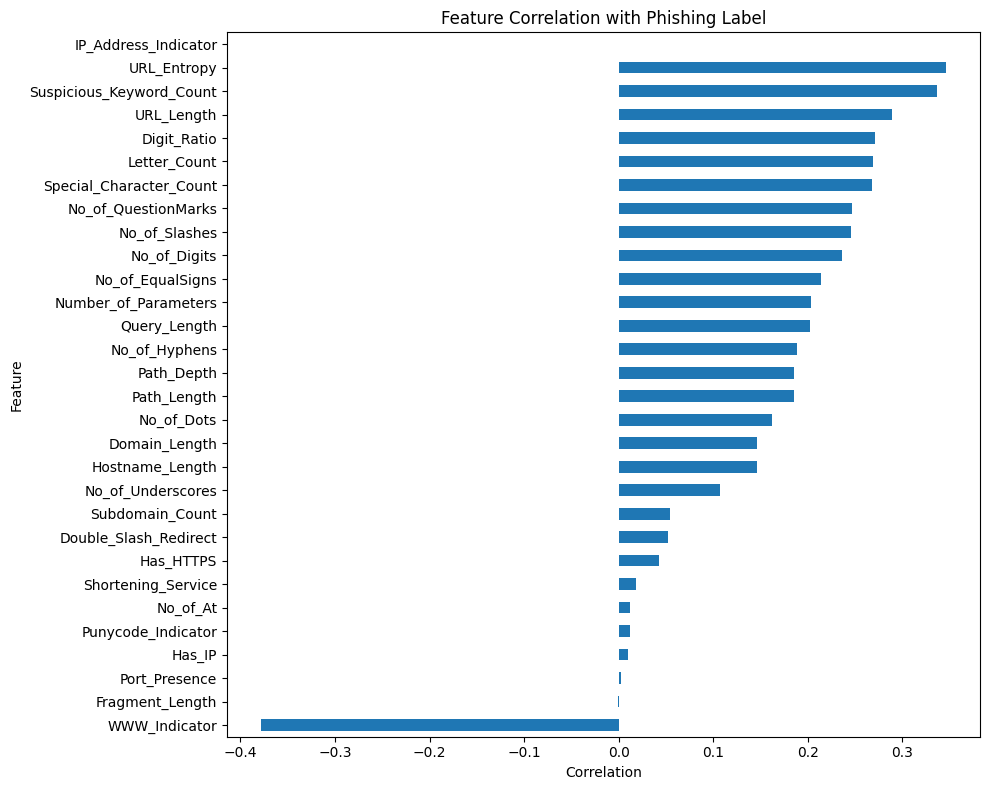

In [ ]:
plt.figure(figsize=(10, 8))

correlation_with_label.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Phishing Label")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Check for highly correlated features

In [ ]:
# Calculate feature-to-feature correlations
feature_corr = df[feature_columns].corr().abs()

# Get the upper triangle
upper = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr_pairs = []

for column in upper.columns:
    for row in upper.index:
        value = upper.loc[row, column]

        if pd.notna(value) and value >= 0.90:
            high_corr_pairs.append(
                (row, column, value)
            )

print("Highly correlated feature pairs (>= 0.90):")

for pair in high_corr_pairs:
    print(
        f"{pair[0]} <--> {pair[1]} : "
        f"{pair[2]:.3f}"
    )

Highly correlated feature pairs (>= 0.90):
Domain_Length <--> Hostname_Length : 1.000
No_of_EqualSigns <--> Number_of_Parameters : 0.919
URL_Length <--> Letter_Count : 0.970


In [ ]:
print(df["IP_Address_Indicator"].value_counts(dropna=False))
print("\nUnique values:", df["IP_Address_Indicator"].nunique())

IP_Address_Indicator
0.0    60042
Name: count, dtype: int64

Unique values: 1


In [ ]:
print(df["Has_IP"].value_counts(dropna=False))
print("\nUnique values:", df["Has_IP"].nunique())

Has_IP
0    59957
1       85
Name: count, dtype: int64

Unique values: 2


In [ ]:
# ============================================================
# FINAL FEATURE SET FOR MODEL 2
# ============================================================

features = [
    "URL_Length",
    "No_of_Dots",
    "No_of_Hyphens",
    "No_of_Digits",
    "Has_HTTPS",
    "No_of_Slashes",
    "No_of_Underscores",
    "No_of_QuestionMarks",
    "No_of_EqualSigns",
    "No_of_At",
    "Has_IP",

    "Domain_Length",
    "Subdomain_Count",
    "Path_Length",
    "Query_Length",
    "Fragment_Length",
    "Path_Depth",
    "Digit_Ratio",
    "Special_Character_Count",
    "Suspicious_Keyword_Count",
    "Shortening_Service",
    "Punycode_Indicator",
    "Port_Presence",
    "Double_Slash_Redirect",
    "WWW_Indicator",
    "URL_Entropy"
]

print("Number of final features:", len(features))

for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

Number of final features: 26
1. URL_Length
2. No_of_Dots
3. No_of_Hyphens
4. No_of_Digits
5. Has_HTTPS
6. No_of_Slashes
7. No_of_Underscores
8. No_of_QuestionMarks
9. No_of_EqualSigns
10. No_of_At
11. Has_IP
12. Domain_Length
13. Subdomain_Count
14. Path_Length
15. Query_Length
16. Fragment_Length
17. Path_Depth
18. Digit_Ratio
19. Special_Character_Count
20. Suspicious_Keyword_Count
21. Shortening_Service
22. Punycode_Indicator
23. Port_Presence
24. Double_Slash_Redirect
25. WWW_Indicator
26. URL_Entropy


FINAL FEATURE SELECTION

In [ ]:
# ============================================================
# FINAL FEATURE SELECTION
# ============================================================

features = [
    "URL_Length",
    "No_of_Dots",
    "No_of_Hyphens",
    "No_of_Digits",
    "Has_HTTPS",
    "No_of_Slashes",
    "No_of_Underscores",
    "No_of_QuestionMarks",
    "No_of_EqualSigns",
    "No_of_At",
    "Has_IP",

    "Domain_Length",
    "Subdomain_Count",
    "Path_Length",
    "Query_Length",
    "Fragment_Length",
    "Path_Depth",
    "Letter_Count",
    "Digit_Ratio",
    "Special_Character_Count",
    "Suspicious_Keyword_Count",
    "Shortening_Service",
    "Punycode_Indicator",
    "Port_Presence",
    "Double_Slash_Redirect",
    "WWW_Indicator",
    "IP_Address_Indicator",
    "URL_Entropy"
]

# Remove the three redundant features
features.remove("Letter_Count")

# Note:
# We are also removing Hostname_Length and Number_of_Parameters
# because they are highly correlated with other features.

features.remove("Hostname_Length") if "Hostname_Length" in features else None
features.remove("Number_of_Parameters") if "Number_of_Parameters" in features else None

print("Number of final features:", len(features))
print("\nFinal features:")

for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

Number of final features: 27

Final features:
1. URL_Length
2. No_of_Dots
3. No_of_Hyphens
4. No_of_Digits
5. Has_HTTPS
6. No_of_Slashes
7. No_of_Underscores
8. No_of_QuestionMarks
9. No_of_EqualSigns
10. No_of_At
11. Has_IP
12. Domain_Length
13. Subdomain_Count
14. Path_Length
15. Query_Length
16. Fragment_Length
17. Path_Depth
18. Digit_Ratio
19. Special_Character_Count
20. Suspicious_Keyword_Count
21. Shortening_Service
22. Punycode_Indicator
23. Port_Presence
24. Double_Slash_Redirect
25. WWW_Indicator
26. IP_Address_Indicator
27. URL_Entropy


Create X and y

In [ ]:
X = df[features]
y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60042, 27)
y shape: (60042,)


Split the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 48033
Testing samples: 12009


Train Improved LightGBM

In [ ]:
from lightgbm import LGBMClassifier

model2 = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31
)

model2.fit(X_train, y_train)

print("Model 2 training completed successfully.")

[LightGBM] [Info] Number of positive: 38321, number of negative: 9712
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1930
[LightGBM] [Info] Number of data points in the train set: 48033, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.797806 -> initscore=1.372636
[LightGBM] [Info] Start training from score 1.372636
Model 2 training completed successfully.


In [ ]:
y_pred2 = model2.predict(X_test)

Improved LightGBM Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy2 = accuracy_score(y_test, y_pred2)

print("Improved LightGBM Accuracy:", accuracy2)
print("Improved LightGBM Accuracy (%):", accuracy2 * 100)

Improved LightGBM Accuracy: 0.9336331085019569
Improved LightGBM Accuracy (%): 93.36331085019569


EVALUATION METRICS

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred2))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      2428
           1       0.96      0.96      0.96      9581

    accuracy                           0.93     12009
   macro avg       0.90      0.90      0.90     12009
weighted avg       0.93      0.93      0.93     12009



In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)

print("Confusion Matrix:")
print(cm2)

Confusion Matrix:
[[2035  393]
 [ 404 9177]]


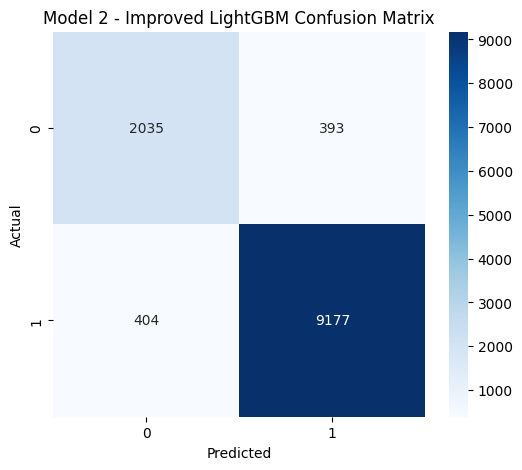

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 - Improved LightGBM Confusion Matrix")

plt.show()

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Accuracy (%):", accuracy_score(y_test, y_pred2) * 100)

Accuracy: 0.9336331085019569
Accuracy (%): 93.36331085019569


In [ ]:
# ============================================================
# MODEL 2 - FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model2.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(importance_df)

Feature Importance:


,Feature,Importance
13,Path_Length,751
11,Domain_Length,611
26,URL_Entropy,554
1,No_of_Dots,466
17,Digit_Ratio,447
12,Subdomain_Count,431
0,URL_Length,399
5,No_of_Slashes,371
18,Special_Character_Count,351
3,No_of_Digits,323


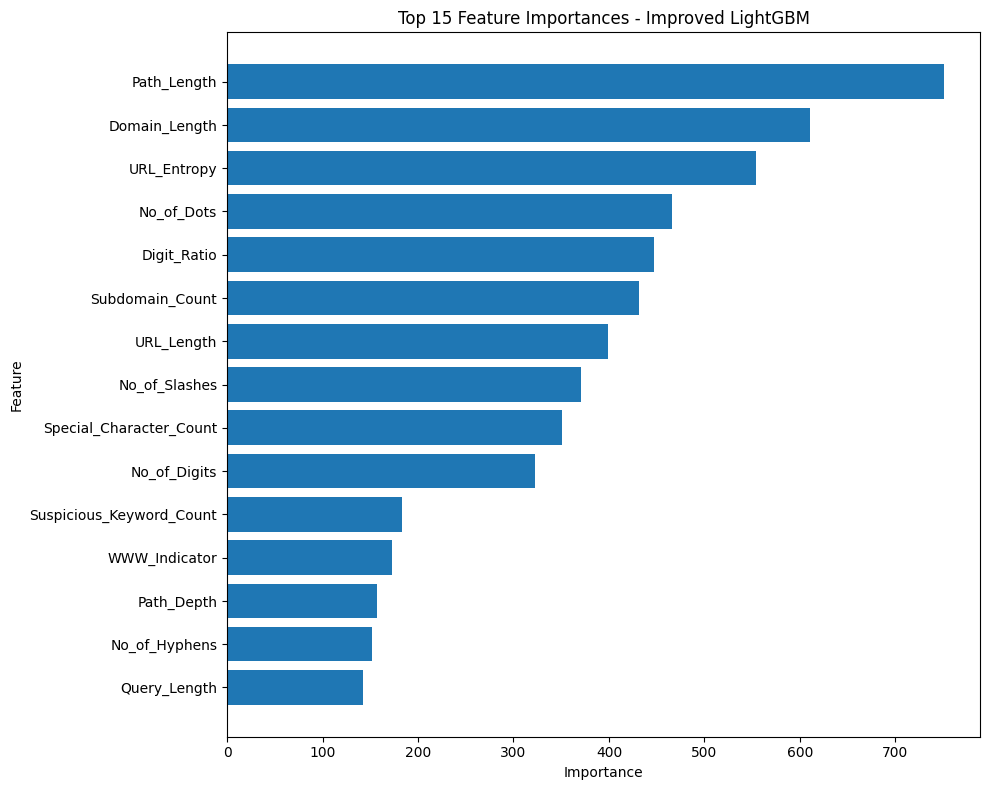

In [ ]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(15).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Improved LightGBM")

plt.tight_layout()
plt.show()

In [ ]:
print("Number of features in X:", X.shape[1])
print("Number of features in model:", model2.n_features_in_)
print("Number of feature names:", len(features))

Number of features in X: 27
Number of features in model: 27
Number of feature names: 27
